# Módulo A.2 — EDA, PCA y Clustering

Analiza el dataset real (`dataset_master_real.csv`), donde se explora las estadísticas, correlaciones, PCA y clustering en relación con las 6 variables bioclimáticas.

## 1. Montar Drive y cargar el dataset real (celda robusta)

In [1]:
import os                       # para comprobar rutas y estado del Drive
from pathlib import Path        # para manejar rutas de forma segura
import pandas as pd             # para cargar y manejar la tabla de datos

# Montar el Drive solo si aún no lo está (evita montarlo dos veces)
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

# Carpeta del proyecto (la misma de los módulos anteriores)
CARPETA_BASE = Path('/content/drive/MyDrive/TFM_TeaSuitability')
RUTA_CSV = CARPETA_BASE / 'dataset_master.csv'  # dataset del A.1 (con pH)

# Si no está el archivo, se avisa mostrando qué hay en la carpeta
if not RUTA_CSV.exists():
    print('No encuentro:', RUTA_CSV)
    for e in sorted(CARPETA_BASE.glob('*')):
        print('  -', e.name)
    raise FileNotFoundError('Falta dataset_master.csv. Ejecuta el A.1.')

dataset = pd.read_csv(RUTA_CSV)          # carga el CSV en una tabla (DataFrame)
print('Cargado. Forma:', dataset.shape)  # (filas, columnas)
dataset.head()                           # muestra las primeras filas

Mounted at /content/drive
Cargado. Forma: (1333, 10)


,lon,lat,clase,temperatura_media,rango_diurno,precipitacion_anual,estacionalidad_precip,precip_trimestre_seco,elevacion,ph_suelo
0,118.013054,29.941719,1,14.924833,7.618333,1670.0,54.601158,158.0,429.0,5.4
1,47.241323,-20.521527,1,16.620459,11.176250,1437.0,87.080925,72.0,1472.0,5.4
2,121.503180,25.163700,1,20.207001,5.704167,3005.0,26.002686,554.0,256.0,4.7
3,121.741242,24.805763,1,20.652042,5.553583,3160.0,35.268108,509.0,297.0,4.9
4,120.603078,23.564246,1,19.789417,5.974333,2526.0,91.668259,76.0,748.0,5.2


## 2. Importaciones

In [2]:
import numpy as np                              # cálculo numérico
import matplotlib.pyplot as plt                 # gráficos base
import seaborn as sns                           # gráficos estadísticos (heatmap)
from sklearn.preprocessing import StandardScaler  # estandarizar variables
from sklearn.decomposition import PCA             # reducción de dimensión
from sklearn.cluster import KMeans, DBSCAN         # algoritmos de clustering
from sklearn.metrics import silhouette_score      # calidad de los clusters

## 3. Variables a analizar

In [3]:
# Lista con las 7 variables ambientales (dejamos fuera lon, lat y clase,
# porque son ubicación y respuesta, no características del entorno).
# Selección alineada con la literatura del té y con el clima tropical de Costa Rica.
columnas_variables = [
    'temperatura_media',        # bio1: temperatura media anual (óptimo del té: 18-25 °C)
    'rango_diurno',             # bio2: diferencia entre la máxima del día y la mínima nocturna
    'precipitacion_anual',      # bio12: lluvia total anual (óptimo 1500-3000 mm)
    'estacionalidad_precip',    # bio15: variación de la lluvia entre estaciones
    'precip_trimestre_seco',    # bio17: lluvia en la estación seca (estrés hídrico)
    'elevacion',                # altitud del terreno (el té se cultiva hasta ~2200 m)
    'ph_suelo',                 # pH del suelo (SoilGrids); el té prefiere ácido, 4.5-5.5
]
print('Nº de variables:', len(columnas_variables))
dataset[columnas_variables].describe().round(2)  # resumen estadístico de cada una

Nº de variables: 7


,temperatura_media,rango_diurno,precipitacion_anual,estacionalidad_precip,precip_trimestre_seco,elevacion,ph_suelo
count,1333.00,1333.00,1333.00,1333.00,1333.00,1333.00,1333.00
mean,17.78,9.61,1523.77,61.07,159.96,615.02,5.86
std,6.74,3.14,933.36,29.85,156.59,703.54,1.01
min,-10.78,4.95,5.00,10.02,0.00,-29.00,3.80
25%,14.41,6.61,816.00,39.97,36.00,149.00,5.20
50%,19.02,9.00,1517.00,53.67,122.00,363.00,5.50
75%,21.90,11.74,2172.00,80.88,208.00,968.00,6.20
max,29.94,20.38,4338.00,183.93,747.00,5485.00,8.90


## 4. Funciones de análisis exploratorio (EDA)

In [4]:
def resumen_exploratorio(dataframe, columnas):
    """
    Muestra estadísticos, balance de clases y valores faltantes.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Tabla con las variables y la columna 'clase'.
    columnas : list of str
        Nombres de las variables a resumir.

    Returns
    -------
    pandas.DataFrame
        Tabla de estadísticos descriptivos de las variables.
    """
    print('Balance de clases:')
    print(dataframe['clase'].value_counts())        # positivos vs negativos
    print('\nFaltantes:', dataframe[columnas].isna().sum().sum())  # deben ser 0
    return dataframe[columnas].describe().round(2)


def graficar_eda(dataframe, columnas):
    """
    Dibuja los histogramas y la matriz de correlación de las variables.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Tabla con las variables.
    columnas : list of str
        Nombres de las variables a graficar.

    Returns
    -------
    None
        Solo dibuja las figuras.
    """
    # histograma de cada variable: forma de su distribución
    dataframe[columnas].hist(figsize=(12, 7), bins=25)
    plt.tight_layout(); plt.show()

    # correlación entre variables (de -1 a 1) como mapa de calor
    plt.figure(figsize=(7, 6))
    sns.heatmap(dataframe[columnas].corr(), annot=True, cmap='coolwarm',
                vmin=-1, vmax=1)
    plt.title('Matriz de correlación (datos reales)')
    plt.tight_layout(); plt.show()

## 5. Funciones de estandarización y PCA

In [5]:
def estandarizar(dataframe, columnas):
    """
    Estandariza las variables a una media de 0 y una desviación estándar de 1.

    Esto es especialmente importante antes de realizar PCA y clustering,
    que dependen de las distancias. Si no escalamos, la variable con mayor magnitud
    (como la elevación) podría dominar el análisis.

    Parameters
    ----------
    dataframe : pandas.DataFrame
        Tabla con las variables.
    columnas : list of str
        Nombres de las variables a estandarizar.

    Returns
    -------
    numpy.ndarray
        Matriz de datos estandarizados.
    sklearn.preprocessing.StandardScaler
        El escalador ya ajustado (reutilizable en producción).
    """
    escalador = StandardScaler()                   # crea el estandarizador
    X = escalador.fit_transform(dataframe[columnas])  # aprende y transforma
    return X, escalador


def aplicar_pca(X_escalado, n_componentes=2):
    """
    Aplica PCA para reducir la dimensión de los datos.

    Parameters
    ----------
    X_escalado : numpy.ndarray
        Datos ya estandarizados.
    n_componentes : int, optional
        Número de componentes a conservar. Por defecto 2.

    Returns
    -------
    numpy.ndarray
        Los datos proyectados en las componentes principales.
    sklearn.decomposition.PCA
        El objeto PCA ajustado (contiene la varianza explicada).
    """
    pca = PCA(n_components=n_componentes)
    componentes = pca.fit_transform(X_escalado)
    return componentes, pca

## 6. Funciones de clustering

In [6]:
def evaluar_k(X_escalado, k_min=2, k_max=7):
    """
    Calcula inercia y silhouette para varios números de grupos (k).

    Ayuda a elegir k con el método del codo (inercia) y el silhouette.

    Parameters
    ----------
    X_escalado : numpy.ndarray
        Datos estandarizados.
    k_min, k_max : int, optional
        Rango de valores de k a probar (k_max incluido). Por defecto 2 y 7.

    Returns
    -------
    dict
        Diccionario con las listas 'k', 'inercias' y 'siluetas'.
    """
    ks, inercias, siluetas = [], [], []
    for k in range(k_min, k_max + 1):
        km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_escalado)
        ks.append(k)
        inercias.append(km.inertia_)                        # compacidad
        siluetas.append(silhouette_score(X_escalado, km.labels_))  # separación
    return {'k': ks, 'inercias': inercias, 'siluetas': siluetas}


def agrupar_kmeans(X_escalado, k):
    """
    Agrupa los datos en k grupos con K-Means.

    Parameters
    ----------
    X_escalado : numpy.ndarray
        Datos estandarizados.
    k : int
        Número de grupos a formar.

    Returns
    -------
    numpy.ndarray
        Etiqueta de grupo (0..k-1) de cada punto.
    """
    return KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_escalado)


def agrupar_dbscan(X_escalado, eps=1.5, min_samples=5):
    """
    Agrupa por densidad con DBSCAN y detecta puntos atípicos.

    Parameters
    ----------
    X_escalado : numpy.ndarray
        Datos estandarizados.
    eps : float, optional
        Radio de vecindad. Por defecto 1.5.
    min_samples : int, optional
        Vecinos mínimos para formar un grupo denso. Por defecto 5.

    Returns
    -------
    numpy.ndarray
        Etiqueta de grupo de cada punto; -1 indica atípico (ruido).
    """
    return DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_escalado)

## 7. Ejecución: EDA

In [7]:
resumen_exploratorio(dataset, columnas_variables)

Balance de clases:
clase
1    780
0    553
Name: count, dtype: int64

Faltantes: 0


,temperatura_media,rango_diurno,precipitacion_anual,estacionalidad_precip,precip_trimestre_seco,elevacion,ph_suelo
count,1333.00,1333.00,1333.00,1333.00,1333.00,1333.00,1333.00
mean,17.78,9.61,1523.77,61.07,159.96,615.02,5.86
std,6.74,3.14,933.36,29.85,156.59,703.54,1.01
min,-10.78,4.95,5.00,10.02,0.00,-29.00,3.80
25%,14.41,6.61,816.00,39.97,36.00,149.00,5.20
50%,19.02,9.00,1517.00,53.67,122.00,363.00,5.50
75%,21.90,11.74,2172.00,80.88,208.00,968.00,6.20
max,29.94,20.38,4338.00,183.93,747.00,5485.00,8.90


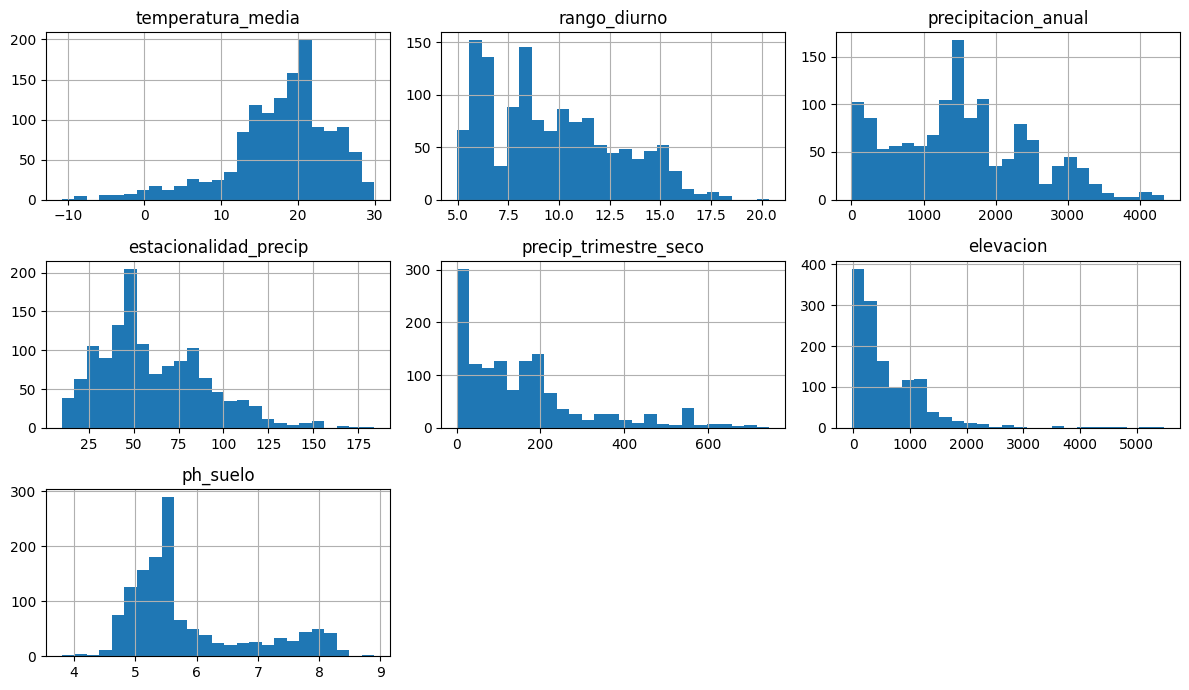

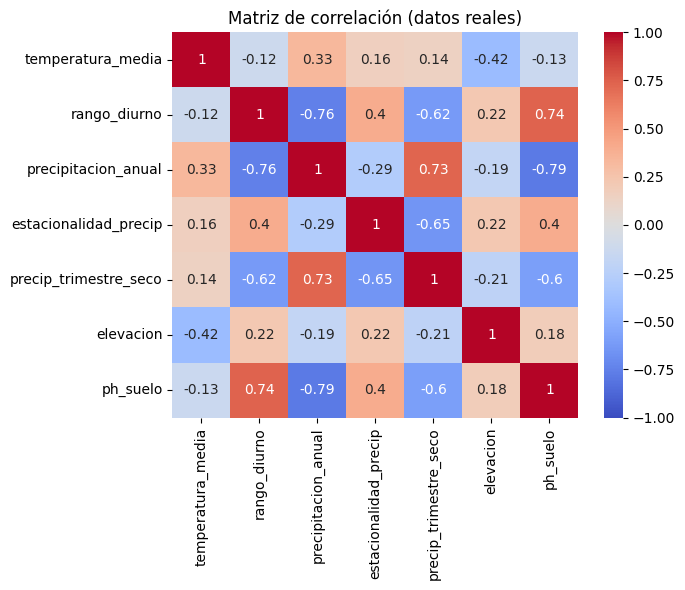

In [8]:
graficar_eda(dataset, columnas_variables)

## 8. Ejecución: estandarización y PCA

In [9]:
X_escalado, escalador = estandarizar(dataset, columnas_variables)
print('Media ~0:', X_escalado.mean(axis=0).round(2))
print('Desv ~1:', X_escalado.std(axis=0).round(2))

Media ~0: [-0.  0.  0. -0.  0. -0.  0.]
Desv ~1: [1. 1. 1. 1. 1. 1. 1.]


Varianza por componente: [0.508 0.194 0.136 0.073 0.039 0.036 0.014]
Acumulada: [0.508 0.702 0.838 0.911 0.95  0.986 1.   ]


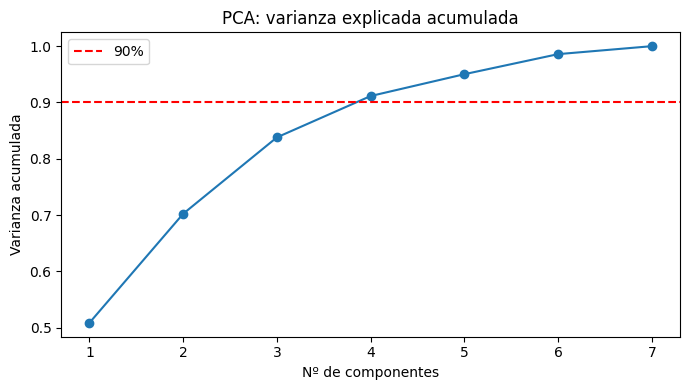

In [10]:
# PCA completo para ver cuánta información conserva cada componente
_, pca_completo = aplicar_pca(X_escalado, n_componentes=len(columnas_variables))
varianza = pca_completo.explained_variance_ratio_
print('Varianza por componente:', varianza.round(3))
print('Acumulada:', varianza.cumsum().round(3))

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(varianza)+1), varianza.cumsum(), marker='o')
plt.axhline(0.9, color='red', ls='--', label='90%')
plt.xlabel('Nº de componentes'); plt.ylabel('Varianza acumulada')
plt.title('PCA: varianza explicada acumulada'); plt.legend()
plt.tight_layout(); plt.show()

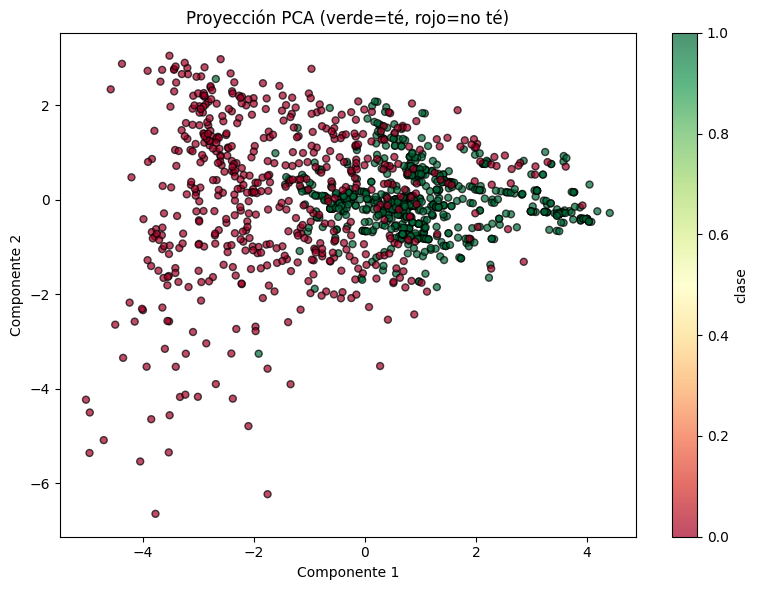

In [11]:
# Proyección en 2 componentes para visualizar, coloreada por clase
componentes, _ = aplicar_pca(X_escalado, n_componentes=2)
plt.figure(figsize=(8, 6))
g = plt.scatter(componentes[:, 0], componentes[:, 1], c=dataset['clase'],
                cmap='RdYlGn', edgecolor='k', s=25, alpha=0.7)
plt.xlabel('Componente 1'); plt.ylabel('Componente 2')
plt.title('Proyección PCA (verde=té, rojo=no té)')
plt.colorbar(g, label='clase'); plt.tight_layout(); plt.show()

## 9. Ejecución: clustering

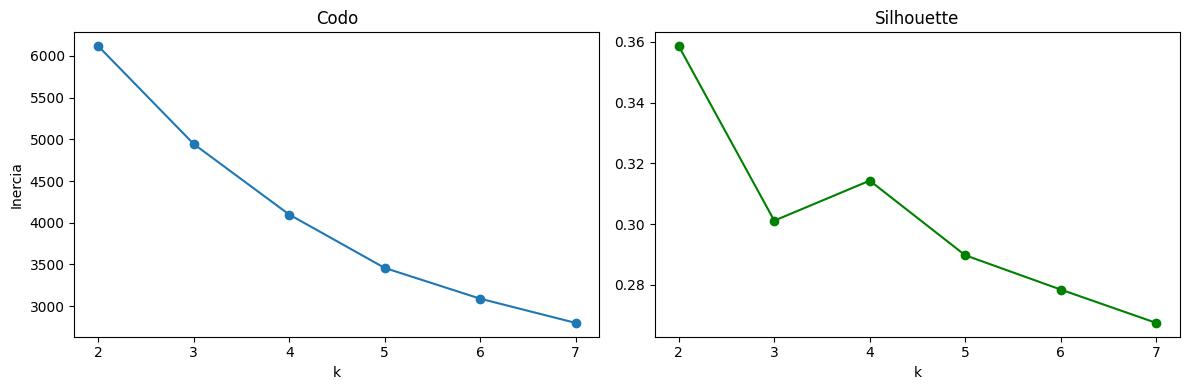

In [12]:
# elegir k con codo + silhouette
resultado_k = evaluar_k(X_escalado, 2, 7)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(resultado_k['k'], resultado_k['inercias'], marker='o'); a1.set_title('Codo')
a1.set_xlabel('k'); a1.set_ylabel('Inercia')
a2.plot(resultado_k['k'], resultado_k['siluetas'], marker='o', color='green')
a2.set_title('Silhouette'); a2.set_xlabel('k')
plt.tight_layout(); plt.show()

Silhouette K-Means (k=3): 0.301
DBSCAN -> clusters: 1 | atípicos: 14


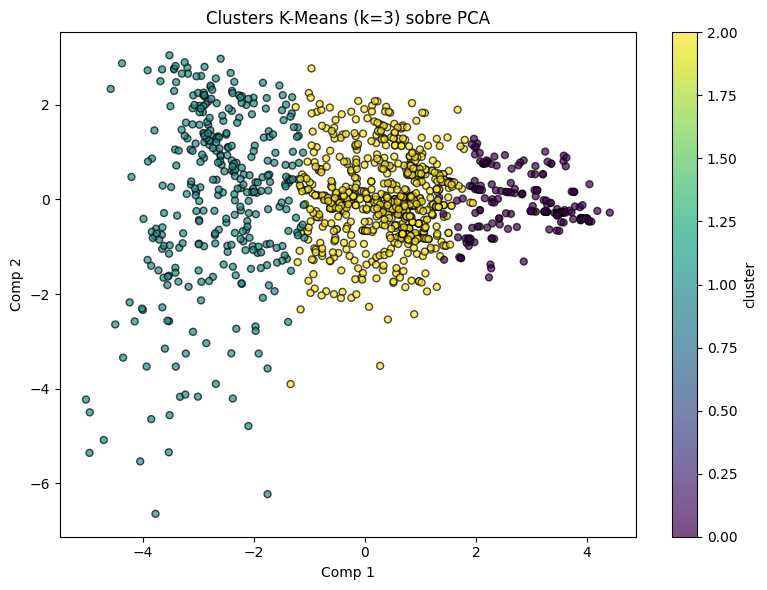

In [13]:
etiquetas_km = agrupar_kmeans(X_escalado, k=3)
etiquetas_db = agrupar_dbscan(X_escalado, eps=1.5, min_samples=5)
print('Silhouette K-Means (k=3):', round(silhouette_score(X_escalado, etiquetas_km), 3))
nc = len(set(etiquetas_db)) - (1 if -1 in etiquetas_db else 0)
print('DBSCAN -> clusters:', nc, '| atípicos:', int((etiquetas_db == -1).sum()))

plt.figure(figsize=(8, 6))
g = plt.scatter(componentes[:, 0], componentes[:, 1], c=etiquetas_km,
                cmap='viridis', edgecolor='k', s=25, alpha=0.7)
plt.title('Clusters K-Means (k=3) sobre PCA')
plt.xlabel('Comp 1'); plt.ylabel('Comp 2')
plt.colorbar(g, label='cluster'); plt.tight_layout(); plt.show()

## 10. Guardar el dataset enriquecido

In [14]:
d = dataset.copy()
d['pca_1'] = componentes[:, 0]
d['pca_2'] = componentes[:, 1]
d['cluster_kmeans'] = etiquetas_km
d['cluster_dbscan'] = etiquetas_db

RUTA_OUT = CARPETA_BASE / 'dataset_master_enriquecido.csv'
d.to_csv(RUTA_OUT, index=False)
print('Guardado en:', RUTA_OUT)
d.head()

Guardado en: /content/drive/MyDrive/TFM_TeaSuitability/dataset_master_enriquecido.csv


,lon,lat,clase,temperatura_media,rango_diurno,precipitacion_anual,estacionalidad_precip,precip_trimestre_seco,elevacion,ph_suelo,pca_1,pca_2,cluster_kmeans,cluster_dbscan
0,118.013054,29.941719,1,14.924833,7.618333,1670.0,54.601158,158.0,429.0,5.4,0.621109,-0.320089,2,0
1,47.241323,-20.521527,1,16.620459,11.176250,1437.0,87.080925,72.0,1472.0,5.4,-0.861451,-0.371881,2,0
2,121.503180,25.163700,1,20.207001,5.704167,3005.0,26.002686,554.0,256.0,4.7,3.501824,-0.299499,0,0
3,121.741242,24.805763,1,20.652042,5.553583,3160.0,35.268108,509.0,297.0,4.9,3.280783,-0.102303,0,0
4,120.603078,23.564246,1,19.789417,5.974333,2526.0,91.668259,76.0,748.0,5.2,0.761332,0.530576,2,0
